**1.  Introduction**

Mental health has become an urgent public health concern across the globe, and Kenya is no exception. Approximately 25% of outpatients and 40% of inpatients in Kenyan healthcare facilities are affected by mental health conditions, according to the Kenyan National Commission of Human Rights. Depression, substance abuse, stress, and anxiety disorders are among the most commonly diagnosed mental health issues in hospital settings, a reflection of an alarming national trend. The situation is compounded by limited data on mental health, neurological issues, and substance use (MNS) in Kenya, making it challenging to address these concerns effectively.


The World Health Organization (WHO) ranks Kenya among the African nations with the highest depression rates, with estimates suggesting that around two million Kenyans are impacted by depression alone. Disturbingly, one in four Kenyans will experience a mental health disorder at some point in their lives.


Given the urgent need to address mental health concerns, this project aims to leverage artificial intelligence to identify and analyze mental health indicators within social media text.

By capturing and analyzing patterns of mental health issues expressed in public discourse, the project seeks to provide insights that can inform policymakers, healthcare providers, and support systems. In doing so, it contributes to a broader understanding of mental health in Kenya and aligns with the national objective of prioritizing mental well-being.

**Problem Statement**








Mental health issues like depression, anxiety, and suicidal tendencies often go unnoticed in daily conversations, especially in online forums, social media posts, or text-based support systems. Existing tools are either too general or overly reliant on structured input, missing subtle signs of mental distress embedded in unstructured conversations. This project aims to identify potential mental health concerns based on users’ language and conversational patterns in online texts.

**Goals and Objectives**

**1.Identify and Categorize Mental Health Issues:**

Develop a model that can accurately classify different mental health issues (e.g., depression, anxiety, suicidal tendencies) based on text data in Reddit posts and comments.

**2.Analyze Language Patterns Linked to Mental Distress:**

 Detect and analyze linguistic features and conversational patterns commonly associated with mental health issues to help distinguish subtle indicators of distress.

 **3.Assess Sentiment and Emotional Intensity:**
 
  Implement sentiment analysis to assess the emotional intensity and tone of the posts and comments, helping to prioritize urgent cases or severe distress

  **4.Provide Actionable Insights for Intervention:**
  
   Generate insights that could support mental health professionals and social media moderators in identifying and addressing potential cases of mental health crises on forums and social platforms.

**2.DATA COLLECTION**

To gather a robust dataset for the Mindcheck project, we utilized the Reddit API through the Python Reddit API Wrapper (PRAW). This approach enabled us to collect a wide range of posts and comments relevant to mental health discussions, positive expressions, and neutral content, which would support the accurate identification and classification of mental health concerns.

we used keyword-based search queries and collected up to 5,000 posts per subreddit. Each post’s title, body, comments, and metadata (e.g., author information, comment scores, timestamps, and subreddit details) were captured to support downstream text analysis. We also included additional post attributes, such as flair, upvote ratios, and crosspost counts, which may serve as helpful features in identifying mental health patterns.

The final dataset was structured and saved as a CSV file for convenient access, providing a comprehensive sample of mental health, positive, and neutral content from Reddit. 

**2.1 DATA UNDERSTANDING**

**DATA LOADING AND IMPORTING RELEVANT LIBRARIES**

In [1]:
# IMPORTING RELEVANT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

In [2]:
#LOADING THE DATASET
data = pd.read_csv("broad_reddit_search_with_labels.csv")

In [3]:
#VIEW FIRST FIVE ROWS
data.head()

,title,post_body,comment_body,comment_score,post_url,created,subreddit,label,post_score,post_num_comments,...,author_premium,distinguished,all_awardings,num_crossposts,total_awards_received,post_thumbnail,link_flair_text,post_id,comment_id,author_flair_text
0,I don't know what's wrong with me,I'm finding it really hard to keep myself toge...,Have you got a therapist on board? Sounds like...,2,https://www.reddit.com/r/mentalhealth/comments...,1.730484e+09,mentalhealth,mental_health_issue,1,1,...,False,NaN,[],0,0,self,Venting,1ghb2bs,luw5fgj,NaN
1,Friends who distance themselves from you or cu...,Please tell me if I sound entitled or selfish....,"I think it’s a combination of factors, and I s...",2,https://www.reddit.com/r/mentalhealth/comments...,1.730480e+09,mentalhealth,mental_health_issue,1,1,...,False,NaN,[],0,0,self,Venting,1gh9prb,luvspbv,NaN
2,sometimes my brain just keeps telling me bad t...,Does anyone else ever get like this? Or have a...,"When I have a panic attack, I tend to think th...",1,https://www.reddit.com/r/mentalhealth/comments...,1.730486e+09,mentalhealth,mental_health_issue,2,2,...,False,NaN,[],0,0,self,Venting,1gh98yg,luwcwu7,NaN
3,sometimes my brain just keeps telling me bad t...,Does anyone else ever get like this? Or have a...,Im wondering if it was simply a panic attack. ...,2,https://www.reddit.com/r/mentalhealth/comments...,1.730487e+09,mentalhealth,mental_health_issue,2,2,...,False,NaN,[],0,0,self,Venting,1gh98yg,luwep2n,NaN
4,Need objective support. I’m in over my head,I feel in over my head and I’m not sure what t...,Please consider seeing a psychologist. Good luck!,1,https://www.reddit.com/r/mentalhealth/comments...,1.730477e+09,mentalhealth,mental_health_issue,1,4,...,False,NaN,[],0,0,self,Need Support,1gh8q6w,luvir86,NaN


**2.2 DATA DESCRIPTION**

In [4]:
#GETTING GENERAL INFORMATION ON NON-NULL COUNTS AND DATA TYPES FOR PER COLUMN
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92395 entries, 0 to 92394
Data columns (total 27 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   title                  92395 non-null  object 
 1   post_body              63730 non-null  object 
 2   comment_body           92395 non-null  object 
 3   comment_score          92395 non-null  int64  
 4   post_url               92395 non-null  object 
 5   created                92395 non-null  float64
 6   subreddit              92395 non-null  object 
 7   label                  92395 non-null  object 
 8   post_score             92395 non-null  int64  
 9   post_num_comments      92395 non-null  int64  
 10  author                 92395 non-null  object 
 11  comment_author         92395 non-null  object 
 12  post_created           92395 non-null  float64
 13  post_flair             35211 non-null  object 
 14  upvote_ratio           92395 non-null  float64
 15  ov

**Description of the data:**

Total Entries: 92,395

Columns: 27, with various data types including object (text), int64 (integer), float64 (floating-point), and bool (boolean).

**Column Breakdown:**

**Title and Post Body:**

 title and post_body contain the main text content of the Reddit posts. post_body has missing values (only 63,730 non-null entries), while title has full entries.
Comment Data: comment_body, comment_score, and comment_author provide information about the main comment associated with each post.

**Meta Information:**

post_url (link to the post), created (timestamp of the comment), and post_created (timestamp of the post) offer metadata. subreddit indicates the community, while label likely represents a category or sentiment associated with the post.

**Post Metrics**
post_score (upvotes) and post_num_comments (comment count) give engagement metrics.

**Author and Flair:** 
author and comment_author identify users, while post_flair and author_flair_text provide flair information, though these are sparsely populated.

**Upvote Ratio and Over 18 Flag:** 

upvote_ratio shows the proportion of upvotes to downvotes, while over_18 flags whether the post is marked for adults.

**Distinguished and Awardings:** 

distinguished appears empty across the dataset, while all_awardings lists any awards received by the post or comment.

**Additional Flags:**
 is_self_post (self-post indicator) and author_premium (premium user status).

**IDs:**
Unique identifiers for each post (post_id) and comment (comment_id).


In [5]:
#CHECK NUMBER OF ROWS AND COLUMNS
data.shape

(92395, 27)

The data set has 92395 rowns and 27 columns

**2.3 DATA CLEANING**

In [6]:
#CHECKING FOR MISSING VALUES
missing_values = data.isnull().sum()
missing_values

title                        0
post_body                28665
comment_body                 0
comment_score                0
post_url                     0
created                      0
subreddit                    0
label                        0
post_score                   0
post_num_comments            0
author                       0
comment_author               0
post_created                 0
post_flair               57184
upvote_ratio                 0
over_18                      0
is_self_post                 0
author_premium               0
distinguished            92395
all_awardings                0
num_crossposts               0
total_awards_received        0
post_thumbnail               0
link_flair_text          57184
post_id                      0
comment_id                   0
author_flair_text        87880
dtype: int64

**Filling Numerical Data (with mean, median, or mode):**

In [7]:
# Fill numerical columns with mean (you can replace 'mean' with 'median' or 'mode')
data['post_score'] = data['post_score'].fillna(data['post_score'].mean())
data['num_crossposts'] = data['num_crossposts'].fillna(data['num_crossposts'].median())
data['upvote_ratio'] = data['upvote_ratio'].fillna(data['upvote_ratio'].mode()[0])

We handle missing values in three columns by replacing them with summary statistics:

**post_score:** Missing values are filled with the mean, representing the average.

**num_crossposts:** Missing values are filled with the median, which is less affected by outliers.

**upvote_ratio:** Missing values are filled with the mode, the most common value, suitable for categorical or ordinal-like data.

Each choice (mean, median, mode) is selected based on the nature of the data, ensuring a more robust and representative dataset for analysis or modeling.

**Filling Categorical or Text Data (with mode or a placeholder):**

In [8]:
# Fill categorical/text columns with 'Unknown' or the most frequent value
data['post_url'] = data['post_url'].fillna('Unknown')  # For text or URL columns
data['author'] = data['author'].fillna(data['author'].mode()[0])  # For author names
data['comment_author'] = data['comment_author'].fillna(data['comment_author'].mode()[0])

# For the 'post_flair' or 'link_flair_text' columns, fill with a placeholder or mode
data['post_flair'] = data['post_flair'].fillna('No flair')
data['link_flair_text'] = data['link_flair_text'].fillna('No flair text')

In [9]:
data['post_id'] = data['post_id'].fillna('Unknown')  # Fill with unknown
data['comment_id'] = data['comment_id'].fillna('Unknown') # Fill with unknown

**Filling with a Specific Value: If you want to fill the null values with a specific value**

In [10]:
data['post_thumbnail'] = data['post_thumbnail'].fillna('No thumbnail')
data['author_flair_text'] = data['author_flair_text'].fillna('No flair')

In [11]:
data['post_body'] = data['post_body'].fillna('No content available')
data['post_body'] = data['post_body'].fillna('')

In [14]:

#Fill with a placeholder (e.g., 'Not distinguished'
data['distinguished'] = data['distinguished'].fillna('Not distinguished')

In [16]:
#CHECK FOR ANY OTHER MISING VALUES
print(data.isnull().sum())

title                    0
post_body                0
comment_body             0
comment_score            0
post_url                 0
created                  0
subreddit                0
label                    0
post_score               0
post_num_comments        0
author                   0
comment_author           0
post_created             0
post_flair               0
upvote_ratio             0
over_18                  0
is_self_post             0
author_premium           0
distinguished            0
all_awardings            0
num_crossposts           0
total_awards_received    0
post_thumbnail           0
link_flair_text          0
post_id                  0
comment_id               0
author_flair_text        0
dtype: int64


In [17]:
#CHECK FOR DUPLICATES

duplicates = data.duplicated()
duplicate_count = duplicates.sum()
duplicate_count

0

**EXPLORATORY DATA ANALYSIS**

**3.1 Bar Plot showing Distribution of Labels**

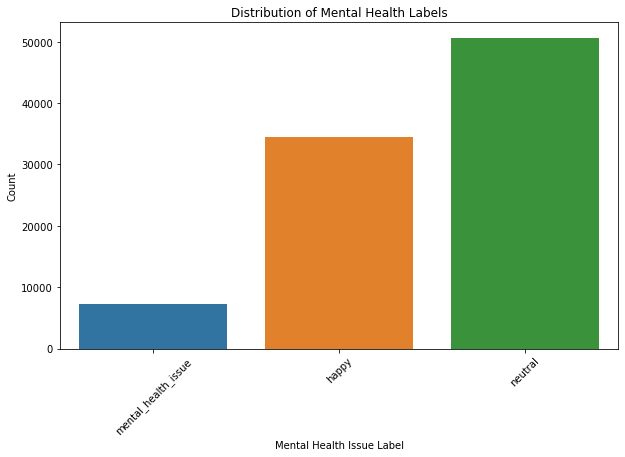

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of labels
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='label')
plt.title("Distribution of Mental Health Labels")
plt.xlabel("Mental Health Issue Label")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

**Insights:**

 The chart shows three categories with varying frequencies. Neutral category (the green bar) has the highest count, followed by the happy/positive category (orange bar), and the lowest is the  mental health issue category (blue bar).


**Implications**

some categories are more prevalent in the  dataset e.g Neutral and happy . This could impact model training, as an imbalanced dataset may lead the model to perform better on the majority category and worse on the minority.

We may need to consider balancing techniques, such as oversampling the minority class or using class weights, to ensure that the model performs well across all categories.


**3.2 Histogram showing Post Length Distribution**

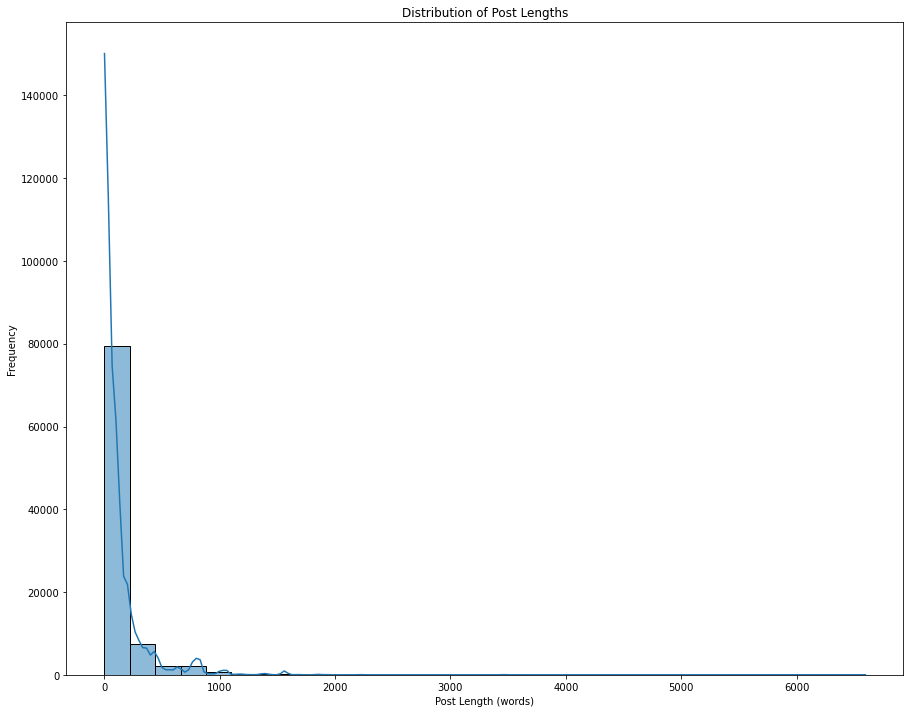

In [19]:
# Calculate the length of each post
data['post_length'] = data['post_body'].apply(lambda x: len(x.split()))

# Plot the distribution of post lengths
plt.figure(figsize=(15, 12))
sns.histplot(data['post_length'], bins=30, kde=True)
plt.title("Distribution of Post Lengths")
plt.xlabel("Post Length (words)")
plt.ylabel("Frequency")
plt.show()

**Insights**

The data is highly skewed to the right, with a large concentration of posts on the left side (lower range).
 This indicates that most posts fall within a lower range  i.e they are shorter than 1000 words , while fewer posts have higher values above 1000 words.

 However, there are some outliers that deviate from the majority  post length and may go up of up to 6,000 words.

 **Implications**

 For modeling, we may handle outliers (very long posts) separately or exclude them if they don't contribute meaningfully to our analysis.

**3.3 Histrogram Showing Distribution of Sentiment Scores**

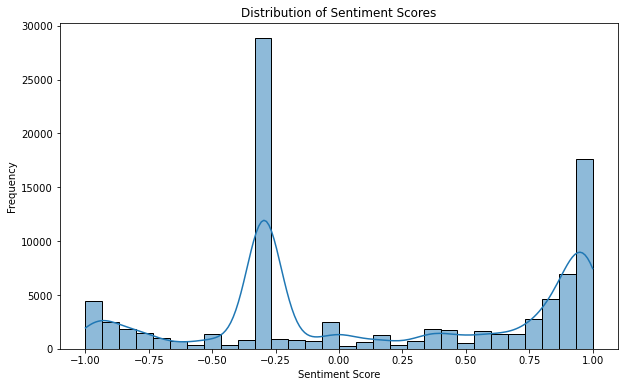

In [20]:
# Initialize the sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Apply VADER sentiment analysis to each post
data['sentiment'] = data['post_body'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

# Plot the sentiment distribution
plt.figure(figsize=(10, 6))
sns.histplot(data['sentiment'], bins=30, kde=True)
plt.title("Distribution of Sentiment Scores")
plt.xlabel("Sentiment Score")
plt.ylabel("Frequency")
plt.show()

**Implications**

Thie Histogram seems to show a bimodal distribution with two distinct peaks.

The two prominent peaks indicate that there are two distinct groups within the data. This could imply two different populations or behaviors within the dataset.

The first peak represents one group whose sentiment score is centered around  -0.25 (fairly negative)  while the second peak represents a differenet  group whose sentiment score is centered around 1(very postive).

Both ends of the histogram show smaller bars, which could represent outliers or infrequent behaviors not fitting into the main clusters.

**Implications**

Given the clear separation between the two peaks, it may be beneficial to treat the two groups separately in our analysis.

This segmentation could allow for more targeted insights or better model performance, especially if the behaviors or language used in each group differ.


Modeling Considerations:

A single model may not capture the nuances across both clusters effectively. We may need to consider building separate models or using clustering techniques to handle each group independently.

**3.4 CO-ORELATION MATRIX FOR NUMERICAL FEATURES**

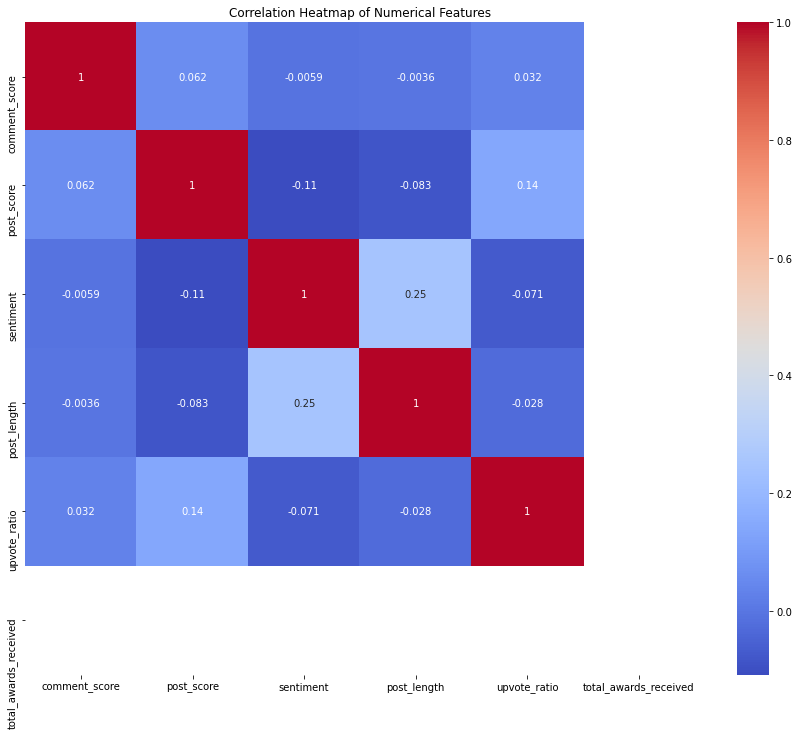

In [21]:
# Selecting numerical features for correlation analysis
numerical_features = ['comment_score', 'post_score', 'sentiment', 'post_length', 'upvote_ratio','total_awards_received','all_awardings']

# Plot the heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(data[numerical_features].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

From our observation the numercial features have very low collinearity to each other and thus may all be considered in our modelling since there is minimal collinearity between them.

**3.5  Clustered Bar Plot showing  Distribution of Labels across Subreddits**

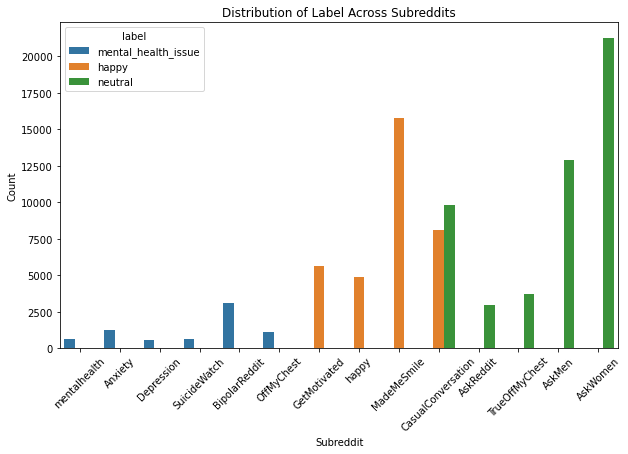

In [22]:
plt.figure(figsize=(10, 6))
sns.countplot(data=data, x='subreddit', hue='label')
plt.title('Distribution of Label Across Subreddits')
plt.xlabel('Subreddit')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()



**Insights and Implications**

**Variation in Label Distribution:**
 The plot shows varying counts of each label (mental_health_issue, happy, and neutral) across different subreddits. Some subreddits have a higher concentration of certain labels, suggesting that these communities may focus on specific emotional or topical content. e,g subreddit suicide watch contains posts that would be flagged as potential  mental health issues

Dominant Emotions per Subreddit: 

For some subreddits, a particular label appears dominant. For example, in certain subreddits such as made me smile , the happy label has higher counts.

Targeted Community Insights:

 Knowing the predominant sentiment within each subreddit can help moderators, researchers, or social media analysts understand the main focus and needs of each community. For example, mental health-focused subreddits may benefit from resources or content specifically aimed at supporting users facing mental health challenges.

**4.0 DATA PREPROCESSING**

To prepare the text data for modeling, We take the following steps:

Converts text to lowercase.

Removes mentions (e.g., @username).

Removes non-alphabetic characters and symbols.

Splits text into words (tokenization).

Removes stop words.

Applies stemming to reduce words to their root form.

In [23]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize

# Ensure you have downloaded the necessary NLTK resources
nltk.download('stopwords')
nltk.download('punkt')

# Initialize stemmer and stop words
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    
    # Remove mentions (e.g., @username)
    text = re.sub(r'@\w+', '', text)

    text = re.sub(r'<.*?>', '', text)  # Remove HTML tags

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Remove non-alphabetic characters and symbols
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    text = re.sub(r'\n', '', text)  # Remove line breaks
    
    # Tokenize
    words = word_tokenize(text)
    
    # Remove stop words and apply stemming
    words = [stemmer.stem(word) for word in words if word not in stop_words]
    
    # Join words back into a single string
    processed_text = ' '.join(words)
    
    return processed_text

# Applying the function to both 'post_body' and 'comment_body' columns
data['cleaned_post_body'] = data['post_body'].apply(lambda x: preprocess_text(str(x)))
data['cleaned_comment_body'] = data['comment_body'].apply(lambda x: preprocess_text(str(x)))

# Display a sample of the processed data
data.head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\PC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


,title,post_body,comment_body,comment_score,post_url,created,subreddit,label,post_score,post_num_comments,...,total_awards_received,post_thumbnail,link_flair_text,post_id,comment_id,author_flair_text,post_length,sentiment,cleaned_post_body,cleaned_comment_body
0,I don't know what's wrong with me,I'm finding it really hard to keep myself toge...,Have you got a therapist on board? Sounds like...,2,https://www.reddit.com/r/mentalhealth/comments...,1.730484e+09,mentalhealth,mental_health_issue,1,1,...,0,self,Venting,1ghb2bs,luw5fgj,No flair,156,-0.9891,im find realli hard keep togeth everi littl in...,got therapist board sound like much hold think...
1,Friends who distance themselves from you or cu...,Please tell me if I sound entitled or selfish....,"I think it’s a combination of factors, and I s...",2,https://www.reddit.com/r/mentalhealth/comments...,1.730480e+09,mentalhealth,mental_health_issue,1,1,...,0,self,Venting,1gh9prb,luvspbv,No flair,125,-0.4647,pleas tell sound entitl selfishi went worst cr...,think combin factor say someon recent cut tie ...
2,sometimes my brain just keeps telling me bad t...,Does anyone else ever get like this? Or have a...,"When I have a panic attack, I tend to think th...",1,https://www.reddit.com/r/mentalhealth/comments...,1.730486e+09,mentalhealth,mental_health_issue,2,2,...,0,self,Venting,1gh98yg,luwcwu7,No flair,360,-0.9656,anyon els ever get like advic work itin past y...,panic attack tend think way bad thing true
3,sometimes my brain just keeps telling me bad t...,Does anyone else ever get like this? Or have a...,Im wondering if it was simply a panic attack. ...,2,https://www.reddit.com/r/mentalhealth/comments...,1.730487e+09,mentalhealth,mental_health_issue,2,2,...,0,self,Venting,1gh98yg,luwep2n,No flair,360,-0.9656,anyon els ever get like advic work itin past y...,im wonder simpli panic attack havent type pani...
4,Need objective support. I’m in over my head,I feel in over my head and I’m not sure what t...,Please consider seeing a psychologist. Good luck!,1,https://www.reddit.com/r/mentalhealth/comments...,1.730477e+09,mentalhealth,mental_health_issue,1,4,...,0,self,Need Support,1gh8q6w,luvir86,No flair,422,0.7680,feel head im sure need object perspect first s...,pleas consid see psychologist good luck


**VISUALIZING COMMON WORDS FOR HAPPY, NEUTRAL AND MENTAL HEALTH SENTIMENTS**